<a href="https://colab.research.google.com/github/alex-smith-uwec/CS491/blob/main/NewYorkerVision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install datasets -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.2/401.2 kB 5.6 MB/s eta 0:00:00


In [3]:
from datasets import load_dataset

from transformers import pipeline
from PIL import Image


In [4]:
newyorker491 = load_dataset("alex-smith/newyorker_CS491")
newyorker491=newyorker491['train']

newyorker491

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/2601 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'contest_number', 'image_location', 'image_description', 'image_uncanny_description', 'questions', 'caption_choices', 'label', 'contest_count', 'scene'],
    num_rows: 2601
})

In [5]:
pipe_large = pipeline("image-to-text", model="microsoft/git-large",max_new_tokens=50)
pipe_base = pipeline("image-to-text", model="microsoft/git-base",max_new_tokens=50)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/2.82k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.58G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/453 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/453 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/503 [00:00<?, ?B/s]

description generated by large model:
 cowboy drawing - a cowboy is thrown off a horse by [ unused0 ]


description generated by base model:
 a cartoon of a horse jumping over a fence.


my description:
 A man was too focused on his phone to motice he fell off his horse 

human description from dataset:
 A man was riding a horse. The horse kicked him off. The man looks happy and is on his phone.


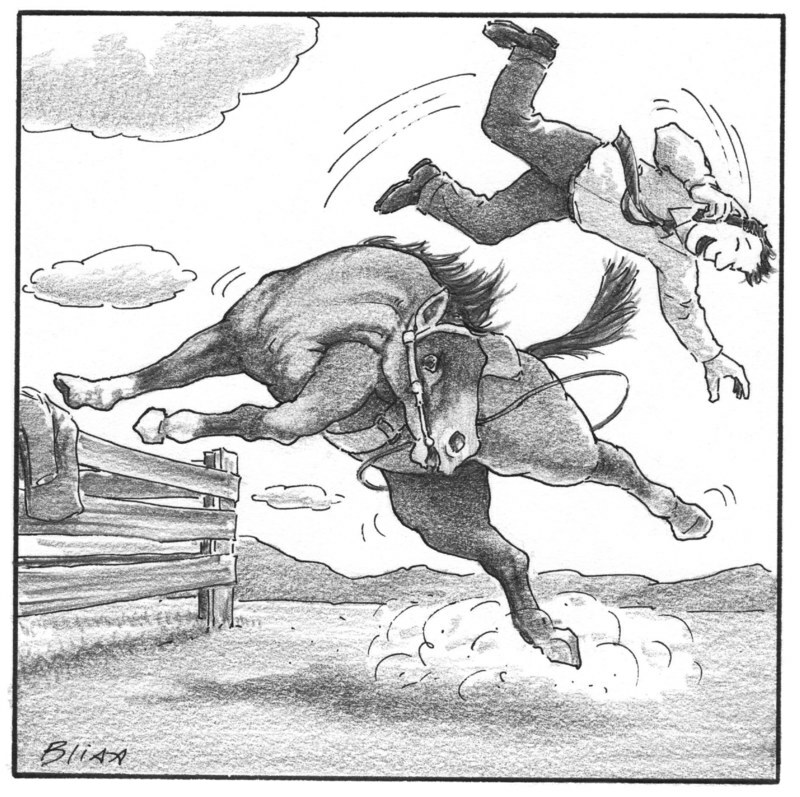

In [6]:
# #Patience--we are feeding the image through through two image to text
# transformers!
k=866
img = newyorker491[k]['image']

# Apply the models to the image
result_large = pipe_large(img)
generated_text_large=result_large[0]['generated_text']

result_base = pipe_base(img)
generated_text_base=result_base[0]['generated_text']
# Print the result
print(f"description generated by large model:\n {generated_text_large}\n\n")
print(f"description generated by base model:\n {generated_text_base}\n\n")
print(f"my description:\n A man was too focused on his phone to motice he fell off his horse \n")

print(f"human description from dataset:\n {newyorker491[k]['image_description']}")
img